# Эксперименты и графики для одного алгоритма слепой деконволюции

Ноутбук для прогона конкретного алгоритма на тестовых датасетах и построения индивидуальных графиков.

**Инструкция по использованию:**
1. **Ячейка 2 (Настройка)** — задать алгоритм, параметры, пути к папкам
2. **Ячейки 3–4 (Датасет)** — настройка датасета + прогон. Копировать эту пару для каждого нового датасета
3. **Последняя ячейка** — финальная сводка по всем датасетам для данного алгоритма

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 1. Общая настройка ноутбука: алгоритм, пути, параметры
# ══════════════════════════════════════════════════════════════════════════════
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from pathlib import Path
from typing import Optional, Dict, List, Tuple
import visualisation as vis  # <-- все графики и TeX-генерация


# ── Автоопределение корня проекта ────────────────────────────────────────────
# Работает независимо от того, где лежит ноутбук: ищем pyproject.toml или src/
_nb_dir = Path(os.path.abspath("")).resolve()
PROJECT_ROOT = _nb_dir
for _p in [_nb_dir] + list(_nb_dir.parents):
    if (_p / "pyproject.toml").exists() or (_p / "src").is_dir():
        PROJECT_ROOT = _p
        break

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)



# ── Настраиваемые параметры ──────────────────────────────────────────────────
ALGORITHM_LABEL = "LIP-PD"   # <-- Менять для каждого алгоритма

DATASETS_ROOT = PROJECT_ROOT / "validate_images"
RESULTS_ROOT  = PROJECT_ROOT / "presentation_graphics"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
ALG_RESULTS_DIR = RESULTS_ROOT / ALGORITHM_LABEL.replace(" ", "_")
ALG_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Параллелизация ───────────────────────────────────────────────────────────
NUM_WORKERS = 3  # Число параллельных процессов (1 = последовательно)

# --- Алгоритм: модуль / класс / параметры (для параллельного воркера) ---
ALG_MODULE = "src.blinddeconv.algorithms.blind_deconvolution.our_company.logarithmic_pds.lip_denoise.lip"
ALG_CLASS = "LIP_BD"
ALG_KERNEL_PARAM = "kernel_shape"  # имя аргумента размера ядра в конструкторе
ALG_KWARGS = {
    'method': 'pd',
    'lambda_val': 30000.0,
    'tau': 1e-3,
    'outer_iters': 140,
    'inner_iters': 5,
    'kernel_threshold': 0.05,
    'final_deconv': 'tikhonov',
    'final_alpha': 0.001,
    'verbose': False,
}

from src.blinddeconv.algorithms.blind_deconvolution.our_company.logarithmic_pds.lip_denoise.lip import LIP_BD

def create_algorithm(kernel_shape=(31, 31)):
    """Создаёт экземпляр алгоритма (для интерактивного использования)."""
    kw = dict(ALG_KWARGS)
    kw[ALG_KERNEL_PARAM] = kernel_shape
    return LIP_BD(**kw)

# ── Утилиты ──────────────────────────────────────────────────────────────────

def parse_distorted_name(filename: str) -> Tuple[Optional[str], Optional[str], Optional[str]]:
    stem = Path(filename).stem
    parts = stem.split("_")
    if len(parts) >= 2:
        return parts[0], parts[1], "_".join(parts[2:]) if len(parts) > 2 else ""
    return stem, None, None

def find_kernel_for_image(kernel_dir: Path, kernel_name: str) -> Optional[Path]:
    if not kernel_dir.exists():
        return None
    for f in kernel_dir.iterdir():
        if f.is_file() and kernel_name in f.stem:
            return f
    return None

def error_ratio_nonblind(original, blurred, true_kernel, est_kernel) -> float:
    """error ratio = MSE(Wiener с est_kernel) / MSE(Wiener с true_kernel)."""
    from numpy.fft import fft2, ifft2
    h, w = blurred.shape[:2]
    reg = 1e-3
    def _wr(y, k):
        K = fft2(k, s=(h, w)); Y = fft2(y, s=(h, w))
        return np.real(ifft2(np.conj(K) * Y / (np.abs(K)**2 + reg)))
    x_true = _wr(blurred, true_kernel)
    x_est  = _wr(blurred, est_kernel)
    orig = original.astype(np.float64)
    mse_true = np.mean((orig - x_true)**2)
    mse_est  = np.mean((orig - x_est)**2)
    return mse_est / mse_true if mse_true > 1e-12 else 1.0

# ── matplotlib настройки ─────────────────────────────────────────────────────
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120,
                     'savefig.dpi': 150, 'savefig.bbox': 'tight'})

ALL_DATASET_RESULTS: List[Dict] = []

print(f"Алгоритм: {ALGORITHM_LABEL}")
print(f"Папка наборов данных: {DATASETS_ROOT}")
print(f"Папка результатов: {ALG_RESULTS_DIR}")

Алгоритм: LIP-PD
Папка наборов данных: D:\for_proga\franework_deconvolution\framework (9)\validate_images
Папка результатов: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\LIP-PD


## Датасет: test1
Ниже две ячейки: настройка датасета + прогон.
Копировать обе ячейки и менять `DATASET_NAME` для нового датасета.

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2a. Настройка текущего датасета
# ══════════════════════════════════════════════════════════════════════════════
DATASET_NAME = "test1"   # <-- Менять для другого датасета
DATASET_DIR = DATASETS_ROOT / DATASET_NAME

# Папки датасета
DIST_DIR   = DATASET_DIR / "distorted"
ORIG_DIR   = DATASET_DIR / "originals"
KERNEL_DIR = DATASET_DIR / "ground_truth_kernels"

# Проверяем наличие
has_originals = ORIG_DIR.exists() and any(ORIG_DIR.iterdir())
has_kernels   = KERNEL_DIR.exists() and any(KERNEL_DIR.iterdir())
has_distorted = DIST_DIR.exists() and any(DIST_DIR.iterdir())

# Папка для результатов этого датасета
DS_RESULT_DIR = ALG_RESULTS_DIR / DATASET_NAME
DS_RESULT_DIR.mkdir(parents=True, exist_ok=True)
(DS_RESULT_DIR / "restored").mkdir(exist_ok=True)
(DS_RESULT_DIR / "kernels").mkdir(exist_ok=True)

print(f"Датасет: {DATASET_NAME}")
print(f"  Искажённые: {has_distorted}  |  Оригиналы: {has_originals}  |  GT ядра: {has_kernels}")
print(f"  Результаты → {DS_RESULT_DIR}")

Датасет: test1
  Искажённые: True  |  Оригиналы: True  |  GT ядра: True
  Результаты → D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\LIP-PD\test1


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2b. Прогон алгоритма на датасете (параллельно)
# ══════════════════════════════════════════════════════════════════════════════
import importlib
import _process_worker; importlib.reload(_process_worker)
from concurrent.futures import ProcessPoolExecutor, as_completed

distorted_files = sorted([f for f in DIST_DIR.iterdir() if f.is_file()])
print(f"Найдено {len(distorted_files)} искажённых изображений  |  Воркеров: {NUM_WORKERS}\n")

# Формируем задания
tasks = []
for dist_file in distorted_files:
    tasks.append({
        'project_root': str(PROJECT_ROOT),
        'dist_file': str(dist_file),
        'orig_dir': str(ORIG_DIR),
        'kernel_dir': str(KERNEL_DIR),
        'has_originals': has_originals,
        'has_kernels': has_kernels,
        'dataset_name': DATASET_NAME,
        'algorithm_label': ALGORITHM_LABEL,
        'alg_module': ALG_MODULE,
        'alg_class': ALG_CLASS,
        'alg_kwargs': ALG_KWARGS,
        'alg_kernel_param': ALG_KERNEL_PARAM,
        'ds_result_dir': str(DS_RESULT_DIR),
    })

# Параллельный / последовательный запуск
results_rows = []
if NUM_WORKERS > 1:
    with ProcessPoolExecutor(
        max_workers=NUM_WORKERS,
        initializer=_process_worker.init_worker,
        initargs=(str(PROJECT_ROOT),),
    ) as pool:
        futures = {pool.submit(_process_worker.process_one, t): t for t in tasks}
        for future in as_completed(futures):
            r = future.result()
            if r is None:
                fname = Path(futures[future]['dist_file']).name
                print(f"✗ {fname}: не удалось загрузить")
            elif 'error' in r:
                print(f"✗ {r['dist_file']}: {r['error']}")
            else:
                results_rows.append(r)
                psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
                er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
                print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")
else:
    for t in tasks:
        r = _process_worker.process_one(t)
        if r is None:
            print(f"✗ {Path(t['dist_file']).name}: не удалось загрузить")
        elif 'error' in r:
            print(f"✗ {r['dist_file']}: {r['error']}")
        else:
            results_rows.append(r)
            psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
            er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
            print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")

# Сохранение CSV
df_results = pd.DataFrame(results_rows)
csv_path = DS_RESULT_DIR / f"results_{ALGORITHM_LABEL}_{DATASET_NAME}.csv"
df_results.to_csv(csv_path, index=False)
print(f"\n{'─'*60}\nОбработано: {len(results_rows)}/{len(tasks)}  |  CSV: {csv_path}")
display(df_results)

# Добавляем в общий список
ALL_DATASET_RESULTS.append({
    'dataset': DATASET_NAME,
    'df': df_results.copy(),
    'dir': DS_RESULT_DIR,
    'has_originals': has_originals,
    'has_kernels': has_kernels,
})

Найдено 3 искажённых изображений  |  Воркеров: 3

✓ cameraman_linear_.png  PSNR=25.81  ER=1.01  t=35.2с
✓ house_largemation_poisson.png  PSNR=17.73  ER=0.98  t=36.0с
✓ airplane_defocus_.png  PSNR=23.99  ER=1.01  t=37.7с

────────────────────────────────────────────────────────────
Обработано: 3/3  |  CSV: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\LIP-PD\test1\results_LIP-PD_test1.csv


,dataset,distorted_file,image_name,kernel_name,noise_name,kernel_shape,time_sec,restored_path,kernel_path,gt_kernel_path,original_path,psnr,ssim,psnr_blurred,ssim_blurred,error_ratio
0,test1,cameraman_linear_.png,cameraman,linear,,"(11, 11)",35.237,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,25.8073,0.7369,20.7172,0.6486,1.0143
1,test1,house_largemation_poisson.png,house,largemation,poisson,"(19, 13)",36.002,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,17.7332,0.1988,22.3872,0.5313,0.9791
2,test1,airplane_defocus_.png,airplane,defocus,,"(19, 19)",37.665,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,23.9855,0.8230,22.3396,0.7369,1.0063


test2

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2a. Настройка текущего датасета
# ══════════════════════════════════════════════════════════════════════════════
DATASET_NAME = "test2"   # <-- Менять для другого датасета
DATASET_DIR = DATASETS_ROOT / DATASET_NAME

# Папки датасета
DIST_DIR   = DATASET_DIR / "distorted"
ORIG_DIR   = DATASET_DIR / "originals"
KERNEL_DIR = DATASET_DIR / "ground_truth_kernels"

# Проверяем наличие
has_originals = ORIG_DIR.exists() and any(ORIG_DIR.iterdir())
has_kernels   = KERNEL_DIR.exists() and any(KERNEL_DIR.iterdir())
has_distorted = DIST_DIR.exists() and any(DIST_DIR.iterdir())

# Папка для результатов этого датасета
DS_RESULT_DIR = ALG_RESULTS_DIR / DATASET_NAME
DS_RESULT_DIR.mkdir(parents=True, exist_ok=True)
(DS_RESULT_DIR / "restored").mkdir(exist_ok=True)
(DS_RESULT_DIR / "kernels").mkdir(exist_ok=True)

print(f"Датасет: {DATASET_NAME}")
print(f"  Искажённые: {has_distorted}  |  Оригиналы: {has_originals}  |  GT ядра: {has_kernels}")
print(f"  Результаты → {DS_RESULT_DIR}")

Датасет: test2
  Искажённые: True  |  Оригиналы: True  |  GT ядра: True
  Результаты → D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\LIP-PD\test2


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2b. Прогон алгоритма на датасете (параллельно)
# ══════════════════════════════════════════════════════════════════════════════
import importlib
import _process_worker; importlib.reload(_process_worker)
from concurrent.futures import ProcessPoolExecutor, as_completed

distorted_files = sorted([f for f in DIST_DIR.iterdir() if f.is_file()])
print(f"Найдено {len(distorted_files)} искажённых изображений  |  Воркеров: {NUM_WORKERS}\n")

# Формируем задания
tasks = []
for dist_file in distorted_files:
    tasks.append({
        'project_root': str(PROJECT_ROOT),
        'dist_file': str(dist_file),
        'orig_dir': str(ORIG_DIR),
        'kernel_dir': str(KERNEL_DIR),
        'has_originals': has_originals,
        'has_kernels': has_kernels,
        'dataset_name': DATASET_NAME,
        'algorithm_label': ALGORITHM_LABEL,
        'alg_module': ALG_MODULE,
        'alg_class': ALG_CLASS,
        'alg_kwargs': ALG_KWARGS,
        'alg_kernel_param': ALG_KERNEL_PARAM,
        'ds_result_dir': str(DS_RESULT_DIR),
    })

# Параллельный / последовательный запуск
results_rows = []
if NUM_WORKERS > 1:
    with ProcessPoolExecutor(
        max_workers=NUM_WORKERS,
        initializer=_process_worker.init_worker,
        initargs=(str(PROJECT_ROOT),),
    ) as pool:
        futures = {pool.submit(_process_worker.process_one, t): t for t in tasks}
        for future in as_completed(futures):
            r = future.result()
            if r is None:
                fname = Path(futures[future]['dist_file']).name
                print(f"✗ {fname}: не удалось загрузить")
            elif 'error' in r:
                print(f"✗ {r['dist_file']}: {r['error']}")
            else:
                results_rows.append(r)
                psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
                er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
                print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")
else:
    for t in tasks:
        r = _process_worker.process_one(t)
        if r is None:
            print(f"✗ {Path(t['dist_file']).name}: не удалось загрузить")
        elif 'error' in r:
            print(f"✗ {r['dist_file']}: {r['error']}")
        else:
            results_rows.append(r)
            psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
            er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
            print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")

# Сохранение CSV
df_results = pd.DataFrame(results_rows)
csv_path = DS_RESULT_DIR / f"results_{ALGORITHM_LABEL}_{DATASET_NAME}.csv"
df_results.to_csv(csv_path, index=False)
print(f"\n{'─'*60}\nОбработано: {len(results_rows)}/{len(tasks)}  |  CSV: {csv_path}")
display(df_results)

# Добавляем в общий список
ALL_DATASET_RESULTS.append({
    'dataset': DATASET_NAME,
    'df': df_results.copy(),
    'dir': DS_RESULT_DIR,
    'has_originals': has_originals,
    'has_kernels': has_kernels,
})

Найдено 3 искажённых изображений  |  Воркеров: 3

✓ boat_dendric_gaussian.png  PSNR=15.05  ER=0.99  t=35.8с
✓ drawing_defocus_pink.png  PSNR=20.92  ER=0.94  t=36.9с
✓ star_heliod_.png  PSNR=17.72  ER=0.91  t=43.1с

────────────────────────────────────────────────────────────
Обработано: 3/3  |  CSV: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\LIP-PD\test2\results_LIP-PD_test2.csv


,dataset,distorted_file,image_name,kernel_name,noise_name,kernel_shape,time_sec,restored_path,kernel_path,gt_kernel_path,original_path,psnr,ssim,psnr_blurred,ssim_blurred,error_ratio
0,test2,boat_dendric_gaussian.png,boat,dendric,gaussian,"(15, 15)",35.832,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,15.0486,0.1004,18.3803,0.3072,0.9896
1,test2,drawing_defocus_pink.png,drawing,defocus,pink,"(19, 19)",36.882,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,20.9228,0.4288,25.5866,0.7392,0.9360
2,test2,star_heliod_.png,star,heliod,,"(31, 31)",43.087,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,17.7228,0.3676,17.7819,0.3416,0.9108


test3

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2a. Настройка текущего датасета
# ══════════════════════════════════════════════════════════════════════════════
DATASET_NAME = "test3"   # <-- Менять для другого датасета
DATASET_DIR = DATASETS_ROOT / DATASET_NAME

# Папки датасета
DIST_DIR   = DATASET_DIR / "distorted"
ORIG_DIR   = DATASET_DIR / "originals"
KERNEL_DIR = DATASET_DIR / "ground_truth_kernels"

# Проверяем наличие
has_originals = ORIG_DIR.exists() and any(ORIG_DIR.iterdir())
has_kernels   = KERNEL_DIR.exists() and any(KERNEL_DIR.iterdir())
has_distorted = DIST_DIR.exists() and any(DIST_DIR.iterdir())

# Папка для результатов этого датасета
DS_RESULT_DIR = ALG_RESULTS_DIR / DATASET_NAME
DS_RESULT_DIR.mkdir(parents=True, exist_ok=True)
(DS_RESULT_DIR / "restored").mkdir(exist_ok=True)
(DS_RESULT_DIR / "kernels").mkdir(exist_ok=True)

print(f"Датасет: {DATASET_NAME}")
print(f"  Искажённые: {has_distorted}  |  Оригиналы: {has_originals}  |  GT ядра: {has_kernels}")
print(f"  Результаты → {DS_RESULT_DIR}")

Датасет: test3
  Искажённые: True  |  Оригиналы: True  |  GT ядра: False
  Результаты → D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\LIP-PD\test3


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2b. Прогон алгоритма на датасете (параллельно)
# ══════════════════════════════════════════════════════════════════════════════
import importlib
import _process_worker; importlib.reload(_process_worker)
from concurrent.futures import ProcessPoolExecutor, as_completed

distorted_files = sorted([f for f in DIST_DIR.iterdir() if f.is_file()])
print(f"Найдено {len(distorted_files)} искажённых изображений  |  Воркеров: {NUM_WORKERS}\n")

# Формируем задания
tasks = []
for dist_file in distorted_files:
    tasks.append({
        'project_root': str(PROJECT_ROOT),
        'dist_file': str(dist_file),
        'orig_dir': str(ORIG_DIR),
        'kernel_dir': str(KERNEL_DIR),
        'has_originals': has_originals,
        'has_kernels': has_kernels,
        'dataset_name': DATASET_NAME,
        'algorithm_label': ALGORITHM_LABEL,
        'alg_module': ALG_MODULE,
        'alg_class': ALG_CLASS,
        'alg_kwargs': ALG_KWARGS,
        'alg_kernel_param': ALG_KERNEL_PARAM,
        'ds_result_dir': str(DS_RESULT_DIR),
    })

# Параллельный / последовательный запуск
results_rows = []
if NUM_WORKERS > 1:
    with ProcessPoolExecutor(
        max_workers=NUM_WORKERS,
        initializer=_process_worker.init_worker,
        initargs=(str(PROJECT_ROOT),),
    ) as pool:
        futures = {pool.submit(_process_worker.process_one, t): t for t in tasks}
        for future in as_completed(futures):
            r = future.result()
            if r is None:
                fname = Path(futures[future]['dist_file']).name
                print(f"✗ {fname}: не удалось загрузить")
            elif 'error' in r:
                print(f"✗ {r['dist_file']}: {r['error']}")
            else:
                results_rows.append(r)
                psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
                er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
                print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")
else:
    for t in tasks:
        r = _process_worker.process_one(t)
        if r is None:
            print(f"✗ {Path(t['dist_file']).name}: не удалось загрузить")
        elif 'error' in r:
            print(f"✗ {r['dist_file']}: {r['error']}")
        else:
            results_rows.append(r)
            psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
            er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
            print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")

# Сохранение CSV
df_results = pd.DataFrame(results_rows)
csv_path = DS_RESULT_DIR / f"results_{ALGORITHM_LABEL}_{DATASET_NAME}.csv"
df_results.to_csv(csv_path, index=False)
print(f"\n{'─'*60}\nОбработано: {len(results_rows)}/{len(tasks)}  |  CSV: {csv_path}")
display(df_results)

# Добавляем в общий список
ALL_DATASET_RESULTS.append({
    'dataset': DATASET_NAME,
    'df': df_results.copy(),
    'dir': DS_RESULT_DIR,
    'has_originals': has_originals,
    'has_kernels': has_kernels,
})

Найдено 3 искажённых изображений  |  Воркеров: 3

✓ boat_wspiral_.png  PSNR=15.95  ER=—  t=41.0с
✓ people_dendric_brown.png  PSNR=15.01  ER=—  t=41.1с
✓ pepper_linear_pink.png  PSNR=16.41  ER=—  t=41.4с

────────────────────────────────────────────────────────────
Обработано: 3/3  |  CSV: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\LIP-PD\test3\results_LIP-PD_test3.csv


,dataset,distorted_file,image_name,kernel_name,noise_name,kernel_shape,time_sec,restored_path,kernel_path,gt_kernel_path,original_path,psnr,ssim,psnr_blurred,ssim_blurred,error_ratio
0,test3,boat_wspiral_.png,boat,wspiral,,"(21, 21)",40.992,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,,D:\for_proga\franework_deconvolution\framework...,15.9531,0.1937,18.0720,0.3861,NaN
1,test3,people_dendric_brown.png,people,dendric,brown,"(21, 21)",41.130,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,,D:\for_proga\franework_deconvolution\framework...,15.0093,0.0542,19.3427,0.2696,NaN
2,test3,pepper_linear_pink.png,pepper,linear,pink,"(21, 21)",41.391,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,,D:\for_proga\franework_deconvolution\framework...,16.4098,0.2108,20.7300,0.5873,NaN


## Финальная сводка: графики и TeX для одного алгоритма

Эта ячейка строит все индивидуальные графики по накопленным данным из `ALL_DATASET_RESULTS`.

Графики:
- 4. PSNR/SSIM в зависимости от итераций (если доступно)
- 5. Сходимость ядра (если доступно)
- 6. Гистограмма распределения error ratio
- 7. Зависимость от шума (если в именах файлов есть информация)
- 8. Зависимость от размера ядра
- 2. Success Rate vs Error Ratio (если есть GT ядра)

Всего обработано изображений: 9



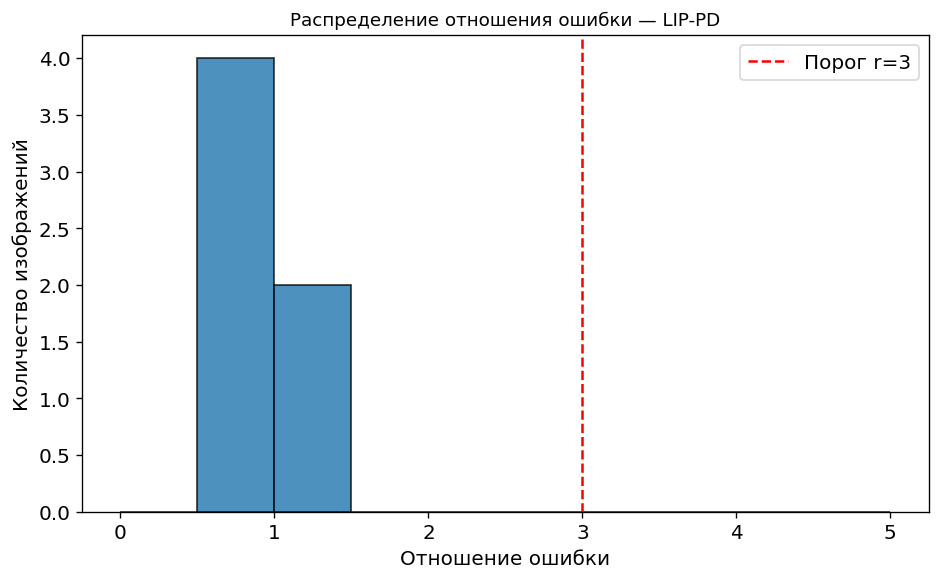

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\LIP-PD\tex\error_ratio_histogram.tex


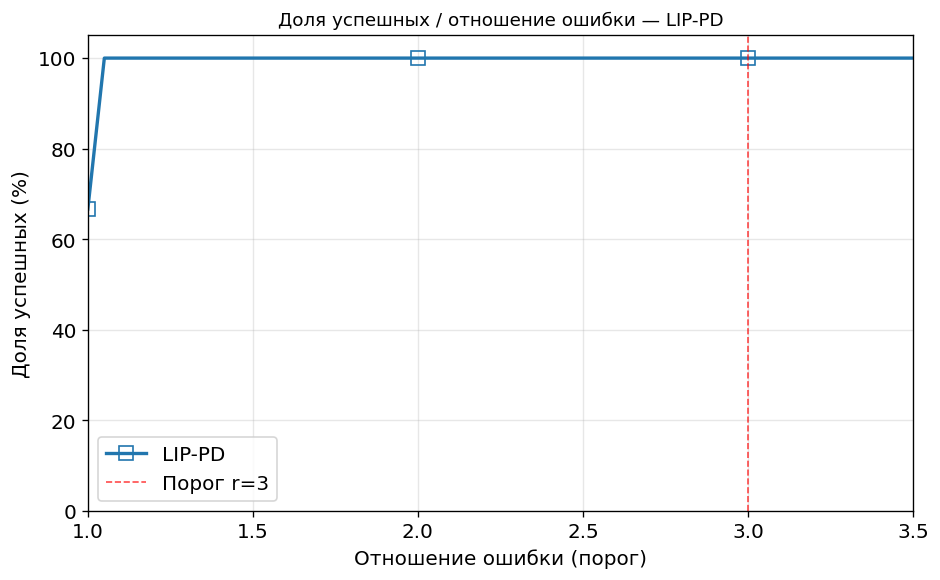

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\LIP-PD\tex\success_rate.tex


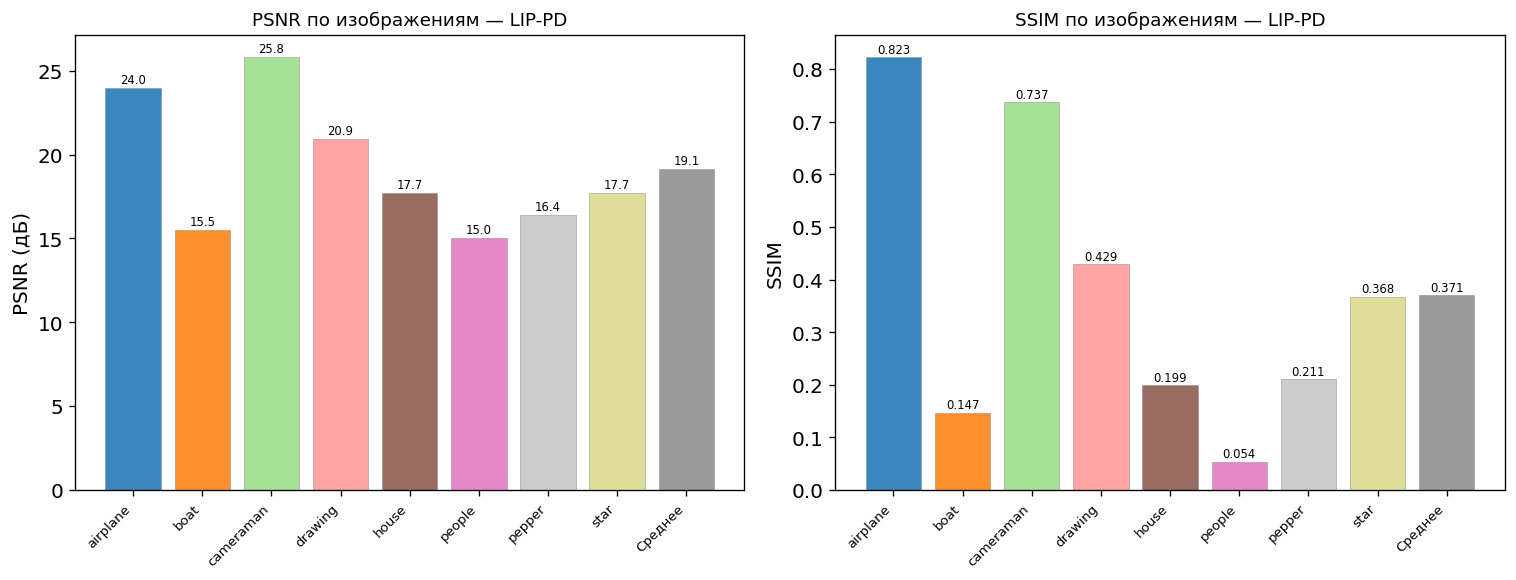

2026-04-14 18:56:33,708 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-14 18:56:33,710 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-14 18:56:33,715 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-14 18:56:33,716 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\LIP-PD\tex\psnr_ssim_bar.tex


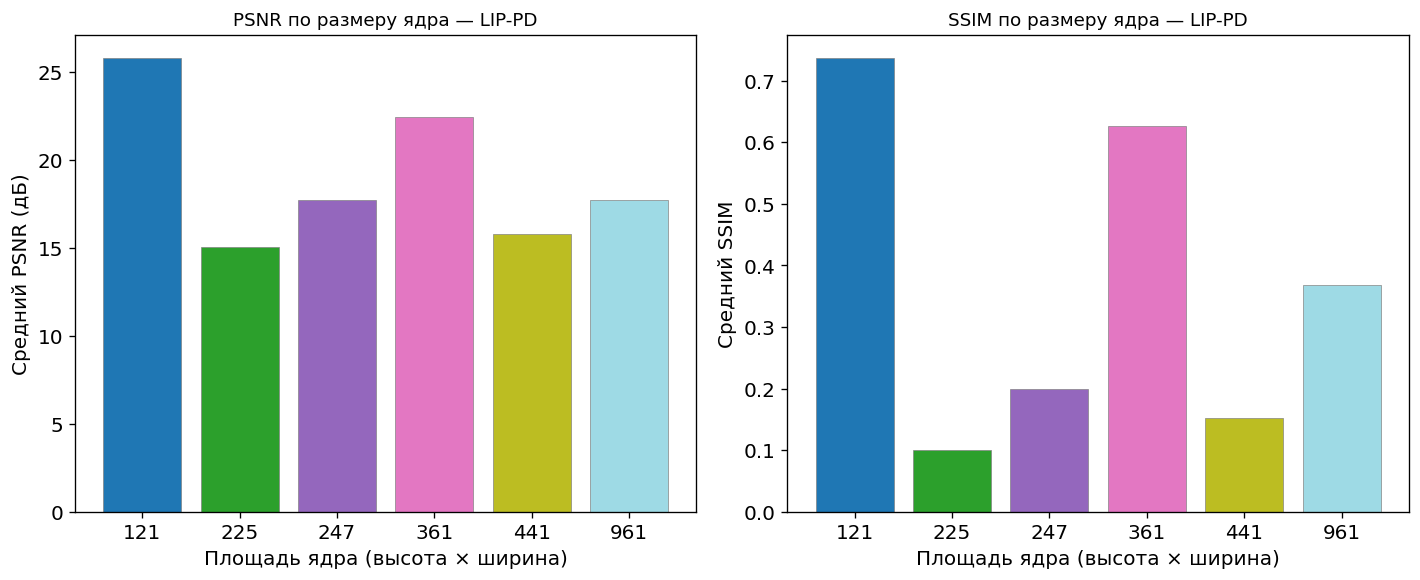

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\LIP-PD\tex\kernel_size_dependency.tex
  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\LIP-PD\tex\summary_table.tex


,Набор данных,Кол-во,PSNR (среднее),SSIM (среднее),Отн. ошибки (среднее),"Время (ср., с)"
0,test1,3,22.51,0.5862,1.0,36.30
1,test2,3,17.90,0.2989,0.95,38.60
2,test3,3,15.79,0.1529,—,41.17



Общий CSV: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\LIP-PD\all_results_LIP-PD.csv


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 3. Финальная сводка для одного алгоритма
# ══════════════════════════════════════════════════════════════════════════════

# Объединяем все результаты
df_all = pd.concat([r['df'] for r in ALL_DATASET_RESULTS], ignore_index=True)
print(f"Всего обработано изображений: {len(df_all)}\n")

TEX_DIR = ALG_RESULTS_DIR / "tex"
TEX_DIR.mkdir(exist_ok=True)
FIG_DIR = ALG_RESULTS_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

# ─── 6. Гистограмма распределения отношения ошибки ───────────────────────────
vis.plot_error_ratio_histogram_single(
    df_all['error_ratio'], ALGORITHM_LABEL, fig_dir=FIG_DIR, tex_dir=TEX_DIR
)

# ─── 2. Доля успешных / отношение ошибки ─────────────────────────────────────
vis.plot_success_rate_single(
    df_all['error_ratio'], ALGORITHM_LABEL, fig_dir=FIG_DIR, tex_dir=TEX_DIR
)

# ─── 3. Столбчатая диаграмма PSNR / SSIM по изображениям ─────────────────────
vis.plot_psnr_ssim_bars_single(
    df_all, ALGORITHM_LABEL, fig_dir=FIG_DIR, tex_dir=TEX_DIR
)

# ─── 8. Зависимость от размера ядра ──────────────────────────────────────────
vis.plot_kernel_size_dependency_single(
    df_all, ALGORITHM_LABEL, fig_dir=FIG_DIR, tex_dir=TEX_DIR
)

# ─── 10. Таблица средних метрик по наборам данных ─────────────────────────────
df_summary = vis.build_summary_single(
    ALL_DATASET_RESULTS, ALGORITHM_LABEL, tex_dir=TEX_DIR
)
display(df_summary)

# Сохраняем объединённый CSV
df_all.to_csv(ALG_RESULTS_DIR / f"all_results_{ALGORITHM_LABEL}.csv", index=False)
print(f"\nОбщий CSV: {ALG_RESULTS_DIR / f'all_results_{ALGORITHM_LABEL}.csv'}")